2026-04-09 16:17:46 - src.utils.file_handler - INFO - Loading CSV from: c:\Users\M.SAMLY\Desktop\student performance prediction\data\processed\train_test_split\train.csv
2026-04-09 16:17:46 - src.utils.file_handler - INFO - Successfully loaded 22814 rows and 22 columns
2026-04-09 16:17:46 - src.utils.file_handler - INFO - Loading CSV from: c:\Users\M.SAMLY\Desktop\student performance prediction\data\processed\train_test_split\validation.csv
2026-04-09 16:17:47 - src.utils.file_handler - INFO - Successfully loaded 3260 rows and 22 columns
2026-04-09 16:17:47 - src.utils.file_handler - INFO - Loading CSV from: c:\Users\M.SAMLY\Desktop\student performance prediction\data\processed\train_test_split\test.csv
2026-04-09 16:17:47 - src.utils.file_handler - INFO - Successfully loaded 6519 rows and 22 columns
Training set: (22814, 21)
Validation set: (3260, 21)
Test set: (6519, 21)
Training Logistic Regression...


c:\Users\M.SAMLY\Desktop\student performance prediction\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training complete!
Training Accuracy: 0.8989
Validation Accuracy: 0.8926

Validation Classification Report:
              precision    recall  f1-score   support

        Fail       0.93      0.86      0.89      1721
        Pass       0.86      0.93      0.89      1539

    accuracy                           0.89      3260
   macro avg       0.89      0.89      0.89      3260
weighted avg       0.90      0.89      0.89      3260

Test Accuracy: 0.9018

Test Classification Report:
              precision    recall  f1-score   support

        Fail       0.93      0.88      0.90      3442
        Pass       0.87      0.93      0.90      3077

    accuracy                           0.90      6519
   macro avg       0.90      0.90      0.90      6519
weighted avg       0.90      0.90      0.90      6519



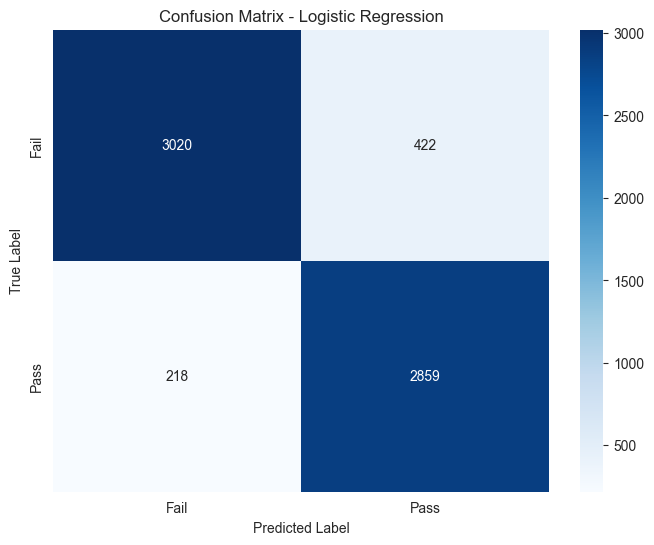

Top 10 Important Features:
                      feature  coefficient  abs_coefficient
20            is_unregistered    -4.526719         4.526719
8        num_of_prev_attempts    -0.796300         0.796300
7   code_presentation_encoded     0.700301         0.700301
18            num_assessments     0.464452         0.464452
6         code_module_encoded    -0.343569         0.343569
0              gender_encoded    -0.337688         0.337688
5          disability_encoded    -0.273515         0.273515
4            age_band_encoded    -0.230884         0.230884
2   highest_education_encoded    -0.178241         0.178241
12     avg_clicks_per_session     0.122804         0.122804


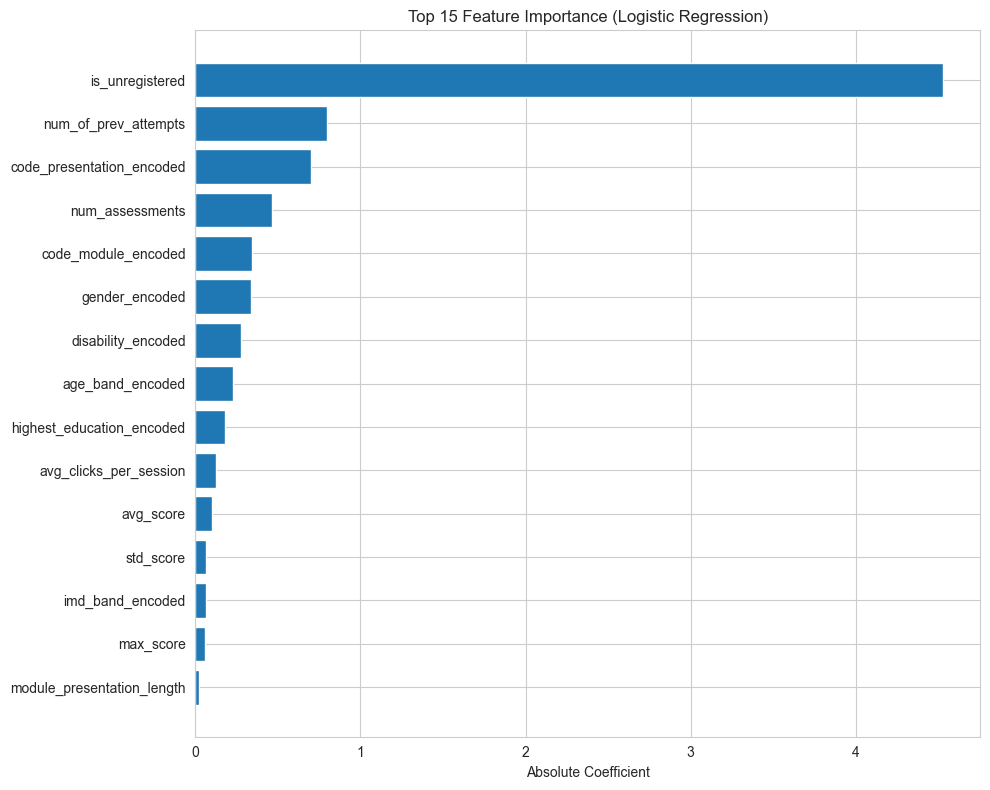

BASELINE MODEL SUMMARY
Model: Logistic Regression
Training Accuracy: 0.8989
Validation Accuracy: 0.8926
Test Accuracy: 0.9018
Number of Features: 21


: 

In [ ]:
### notebooks/03_baseline_model.ipynb
# Cell 1: Setup
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from src.config import PROCESSED_DATA_DIR, MODELS_DIR
from src.utils.file_handler import load_csv, load_json

sns.set_style("whitegrid")

# Cell 2: Load Data
splits_dir = PROCESSED_DATA_DIR / "train_test_split"

train_data = load_csv(splits_dir / "train.csv")
val_data = load_csv(splits_dir / "validation.csv")
test_data = load_csv(splits_dir / "test.csv")

X_train = train_data.drop('pass_fail', axis=1)
y_train = train_data['pass_fail']

X_val = val_data.drop('pass_fail', axis=1)
y_val = val_data['pass_fail']

X_test = test_data.drop('pass_fail', axis=1)
y_test = test_data['pass_fail']

print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test.shape}")

# Cell 3: Train Baseline Model
print("Training Logistic Regression...")

model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

print("Training complete!")

# Cell 4: Training Performance
y_train_pred = model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")

# Cell 5: Validation Performance
y_val_pred = model.predict(X_val)
val_accuracy = accuracy_score(y_val, y_val_pred)

print(f"Validation Accuracy: {val_accuracy:.4f}")
print("\nValidation Classification Report:")
print(classification_report(y_val, y_val_pred, target_names=['Fail', 'Pass']))

# Cell 6: Test Performance
y_test_pred = model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Test Accuracy: {test_accuracy:.4f}")
print("\nTest Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=['Fail', 'Pass']))

# Cell 7: Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fail', 'Pass'],
            yticklabels=['Fail', 'Pass'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Cell 8: Feature Importance
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': model.coef_[0],
    'abs_coefficient': np.abs(model.coef_[0])
}).sort_values('abs_coefficient', ascending=False)

print("Top 10 Important Features:")
print(feature_importance.head(10))

# Cell 9: Plot Feature Importance
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['abs_coefficient'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Absolute Coefficient')
plt.title('Top 15 Feature Importance (Logistic Regression)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Cell 10: Model Summary
print("="*60)
print("BASELINE MODEL SUMMARY")
print("="*60)
print(f"Model: Logistic Regression")
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Number of Features: {X_train.shape[1]}")